In [1]:
!pip install "numpy==2.0.2" pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 103.0 MB/s eta 0:00:00


In [2]:
"""
evaluation_schemes.py

"""

import numpy as np
from sklearn.metrics import f1_score, hamming_loss, classification_report



def exact_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    
    assert gold.shape == preds.shape, "gold and preds must have the same shape"

    # Row-wise equality: True only when ALL labels in a row match
    row_matches = np.all(gold == preds, axis=1)          # (N,) bool
    emr = float(row_matches.mean())                      # Exact Match Ratio

    # For a strict binary decision (match vs. no-match):
    #   TP = matched samples, FP = 0, FN = 0  →  P = R = F1 = EMR
    return {
        "precision"         : emr,
        "recall"            : emr,
        "f1"                : emr,
        "exact_match_ratio" : emr,
        "num_exact_matches" : int(row_matches.sum()),
    }



def _instance_prf(gold_row: np.ndarray, pred_row: np.ndarray):
    
    gold_set = set(np.where(gold_row == 1)[0])
    pred_set = set(np.where(pred_row == 1)[0])

    # Both empty → perfect prediction
    if len(gold_set) == 0 and len(pred_set) == 0:
        return 1.0, 1.0, 1.0

    # One empty, the other not → zero overlap
    if len(gold_set) == 0 or len(pred_set) == 0:
        return 0.0, 0.0, 0.0

    overlap = len(gold_set & pred_set)
    precision = overlap / len(pred_set)
    recall    = overlap / len(gold_set)
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    return precision, recall, f1


def partial_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    
    assert gold.shape == preds.shape

    precisions, recalls, f1s = [], [], []
    for g_row, p_row in zip(gold, preds):
        p, r, f = _instance_prf(g_row, p_row)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)

    return {
        "precision" : float(np.mean(precisions)),
        "recall"    : float(np.mean(recalls)),
        "f1"        : float(np.mean(f1s)),
    }

def evaluate_all_schemes(
    gold: np.ndarray,
    preds: np.ndarray,
    label_names: list[str] | None = None,
    verbose: bool = True,
) -> dict:
    

    # ── Scheme 1 : Per-label sklearn metrics ──────────────────────────────────
    scheme1 = {
        "macro_f1"    : f1_score(gold, preds, average="macro",    zero_division=0),
        "micro_f1"    : f1_score(gold, preds, average="micro",    zero_division=0),
        "weighted_f1" : f1_score(gold, preds, average="weighted", zero_division=0),
        "hamming_loss": hamming_loss(gold, preds),
    }

    # ── Scheme 2 : Exact match ────────────────────────────────────────────────
    scheme2 = exact_match_scores(gold, preds)

    # ── Scheme 3 : Partial match ──────────────────────────────────────────────
    scheme3 = partial_match_scores(gold, preds)

    results = {"scheme1": scheme1, "scheme2": scheme2, "scheme3": scheme3}

    if verbose:
        _print_report(results, gold, preds, label_names)

    return results


def _print_report(results, gold, preds, label_names):
    sep = "=" * 62

    print(sep)
    print("  SCHEME 1 – Per-label sklearn metrics  (existing baseline)")
    print(sep)
    s1 = results["scheme1"]
    print(f"  Macro  F1      : {s1['macro_f1']:.4f}")
    print(f"  Micro  F1      : {s1['micro_f1']:.4f}")
    print(f"  Weighted F1    : {s1['weighted_f1']:.4f}")
    print(f"  Hamming Loss   : {s1['hamming_loss']:.4f}")
    if label_names:
        print("\n  Per-label classification report:")
        print(
            classification_report(
                gold, preds,
                target_names=label_names,
                digits=4,
                zero_division=0,
            )
        )

    print(sep)
    print("  SCHEME 2 – Exact Match")
    print(sep)
    s2 = results["scheme2"]
    print(f"  Exact Match Ratio (EMR) : {s2['exact_match_ratio']:.4f}")
    print(f"  Num Exact Matches       : {s2['num_exact_matches']}")
    print(f"  Precision               : {s2['precision']:.4f}")
    print(f"  Recall                  : {s2['recall']:.4f}")
    print(f"  F1                      : {s2['f1']:.4f}")
    print("  [Note: P = R = F1 = EMR for strict exact-match scoring]")

    print(sep)
    print("  SCHEME 3 – Partial Match  (instance-level set overlap)")
    print(sep)
    s3 = results["scheme3"]
    print(f"  Precision (macro-inst.) : {s3['precision']:.4f}")
    print(f"  Recall    (macro-inst.) : {s3['recall']:.4f}")
    print(f"  F1        (macro-inst.) : {s3['f1']:.4f}")
    print(sep)



if __name__ == "__main__":
    rng = np.random.default_rng(42)

    EMOTION_COLS = ["Love", "Joy", "Surprise", "Anger", "Sadness", "Fear"]

    # Simulate gold labels and predictions
    gold  = (rng.random((50, 6)) > 0.6).astype(int)
    preds = gold.copy()

    # Flip ~15 % of bits to simulate imperfect predictions
    flip_mask = rng.random((50, 6)) < 0.15
    preds[flip_mask] = 1 - preds[flip_mask]

    # --- Manual examples from the task description ---
    print("Manual example checks")
    print("-" * 40)

    g1 = np.array([[0, 0, 1, 1, 0, 1]])
    p1 = np.array([[0, 0, 1, 1, 0, 1]])   # perfect
    g2 = np.array([[0, 0, 1, 1, 0, 1]])
    p2 = np.array([[0, 0, 1, 1, 0, 0]])   # one label off

    print("Example 1 (perfect):")
    print(f"  Exact match score  : {exact_match_scores(g1, p1)['exact_match_ratio']}")
    print(f"  Partial match F1   : {partial_match_scores(g1, p1)['f1']:.4f}")

    print("Example 2 (one label off):")
    print(f"  Exact match score  : {exact_match_scores(g2, p2)['exact_match_ratio']}")
    print(f"  Partial match F1   : {partial_match_scores(g2, p2)['f1']:.4f}")

    print("\nFull 50-sample evaluation:")
    evaluate_all_schemes(gold, preds, label_names=EMOTION_COLS, verbose=True)

Manual example checks
----------------------------------------
Example 1 (perfect):
  Exact match score  : 1.0
  Partial match F1   : 1.0000
Example 2 (one label off):
  Exact match score  : 0.0
  Partial match F1   : 0.8000

Full 50-sample evaluation:
  SCHEME 1 – Per-label sklearn metrics  (existing baseline)
  Macro  F1      : 0.8069
  Micro  F1      : 0.8097
  Weighted F1    : 0.8147
  Hamming Loss   : 0.1567

  Per-label classification report:
              precision    recall  f1-score   support

        Love     0.7826    0.8182    0.8000        22
         Joy     0.7727    0.8500    0.8095        20
    Surprise     0.5714    0.8571    0.6857        14
       Anger     0.8095    0.9444    0.8718        18
     Sadness     0.6667    0.8421    0.7442        19
        Fear     0.9524    0.9091    0.9302        22

   micro avg     0.7576    0.8696    0.8097       115
   macro avg     0.7592    0.8702    0.8069       115
weighted avg     0.7727    0.8696    0.8147       115
 samp

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, hamming_loss
)
from sklearn.utils.class_weight import compute_class_weight

from tqdm import tqdm
import pennylane as qml

try:
    from evaluation_schemes import evaluate_all_schemes
except ModuleNotFoundError:
    pass  # already defined by the pasted code cell above

In [4]:
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

print("GPU device:", gpu_device)
print("CPU device:", cpu_device)

GPU device: cuda
CPU device: cpu


In [5]:
def set_seed(seed_value=42):
    """Set seeds for reproducibility across PyTorch, NumPy, and Python."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

In [6]:
import glob
DATA_DIR = '../BanglaEmotion _1/dataset'
if not os.path.exists(DATA_DIR):
    txt_files = sorted(glob.glob('/kaggle/input/**/train.txt', recursive=True))
    assert len(txt_files) >= 1, 'train.txt not found under /kaggle/input'
    DATA_DIR = txt_files[0].rsplit('/', 1)[0]

def load_txt(path):
    """Parse '<label> <text>' per line -> DataFrame with 'Data' + 'Label' cols."""
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            label, _, text = line.partition(' ')
            rows.append((text.strip(), label.strip()))
    return pd.DataFrame(rows, columns=['Data', 'Label'])

df_tr = load_txt(f'{DATA_DIR}/train.txt')
df_te = load_txt(f'{DATA_DIR}/test.txt')

# Stratified hold-out for validation (test.txt stays untouched)
df_tr, df_vl = train_test_split(
    df_tr, test_size=0.15, random_state=42, stratify=df_tr['Label']
)
df_tr = df_tr.reset_index(drop=True)
df_vl = df_vl.reset_index(drop=True)
df_te = df_te.reset_index(drop=True)

print('Train:', df_tr.shape, '| Valid:', df_vl.shape, '| Test:', df_te.shape)
df_tr.head()


Train: (3995, 2) | Valid: (705, 2) | Test: (940, 2)


,Data,Label
0,Dr. Imran H Sarker সবাইকেই ঐক্যবদ্ধ হয়ে অন্যায়...,happy
1,চল সবাই মিলে শাহবাগে গিয়ে আন্দোলন শুরু করি,happy
2,কি ভাবে বাংলার মানুশকে বোজান হল জে তনু নিজাতিত...,fear
3,এইভাবে আপনার action চালিয়ে জান। প্রবাসীরা আপনা...,happy
4,এই প্রথম বিমান সিকিউরিটির ঐকটা ভাল কাজ দেকলাম ...,happy


In [7]:
# Derive label set from the actual data so EMOTION_COLS always matches
# what is present – this prevents the ValueError in compute_class_weight
# when the hardcoded list diverges from the file contents.
all_labels   = sorted(set(df_tr['Label'].unique()) |
                      set(df_vl['Label'].unique()) |
                      set(df_te['Label'].unique()))
EMOTION_COLS = all_labels
TEXT_COL     = 'Data'
NUM_LABELS   = len(EMOTION_COLS)

for split_name, split_df in [('Train', df_tr), ('Valid', df_vl), ('Test', df_te)]:
    assert TEXT_COL in split_df.columns, f"{split_name}: missing column '{TEXT_COL}'"
    assert 'Label' in split_df.columns, f"{split_name}: missing column 'Label'"

print(f'NUM_LABELS = {NUM_LABELS}  →  {EMOTION_COLS}')
print('\nTrain label distribution:')
print(df_tr['Label'].value_counts())

NUM_LABELS = 6  →  ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise']

Train label distribution:
Label
happy       1275
sad          850
angry        850
disgust      425
surprise     340
fear         255
Name: count, dtype: int64


In [8]:
class EmoNoBaDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.data      = df
        self.tokenizer = tokenizer
        self.max_len   = max_length
        self.label2idx = {lbl: i for i, lbl in enumerate(EMOTION_COLS)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        encoding = self.tokenizer(
            str(row[TEXT_COL]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        label = torch.tensor(
            self.label2idx[row['Label']],
            dtype=torch.long
        )

        return (
            encoding['input_ids'].squeeze(0),       # (max_length,)
            encoding['attention_mask'].squeeze(0),  # (max_length,)
            label                                   # () long, single class index
        )

In [9]:
TEXT_MODEL   = 'csebuetnlp/banglabert'

tokenizer    = AutoTokenizer.from_pretrained(TEXT_MODEL)
text_encoder = AutoModel.from_pretrained(TEXT_MODEL).to(gpu_device)

print("Text encoder loaded on:", next(text_encoder.parameters()).device)

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
electra.embeddings.position_ids                   | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text encoder loaded on: cuda:0


[tensor(0.31092093, requires_grad=True), tensor(-0.361872, requires_grad=True), tensor(-0.22137041, requires_grad=True), tensor(0.07806956, requires_grad=True)]


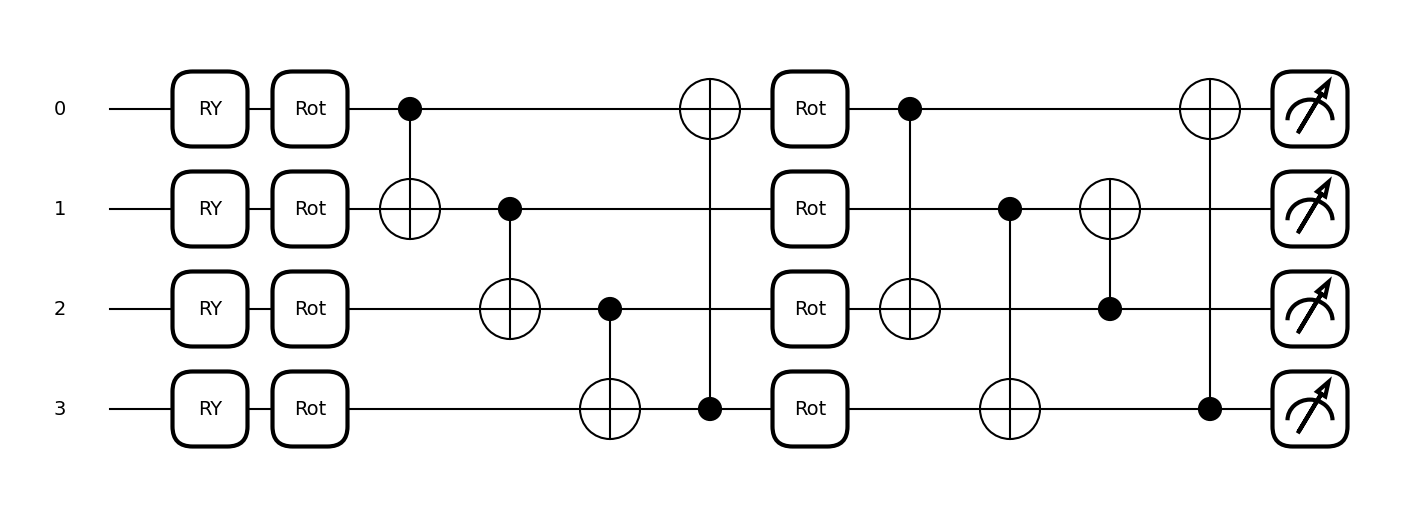

In [10]:
"""

ADD YOUR VQC HERE ...

"""
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

n_qubits = 4
n_qlayers = 1

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def vqc(inputs, weights):

    # Feature Encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Variational Layer
    for i in range(n_qubits):
        qml.Rot(
            weights[0][i][0],
            weights[0][i][1],
            weights[0][i][2],
            wires=i
        )

    # Ring Entanglement
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])
    qml.CNOT(wires=[3,0])

    #2nd Variational Layer
    for i in range(n_qubits):
        qml.Rot(
            weights[0][i][0],
            weights[0][i][1],
            weights[0][i][2],
            wires=i
        )

          # Ring Entanglement
    qml.CNOT(wires=[0,2])
    qml.CNOT(wires=[1,3])
    qml.CNOT(wires=[2,1])
    qml.CNOT(wires=[3,0])



    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

inputs = np.array([0.5,1.0,1.5,2.0])

weights = np.random.random((1,4,3))

print(vqc(inputs, weights))

# Draw the circuit
fig, ax = qml.draw_mpl(vqc)(inputs, weights)
plt.show()

In [11]:
class QuantumBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        # StronglyEntanglingLayers weight shape: (n_layers, n_qubits, 3)
        self.weights = nn.Parameter(
            torch.randn(n_qlayers, n_qubits, 3)   # ← was (N_Q_LAYERS, N_QUBITS)
        )

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            out = torch.stack(vqc(x[i].cpu(),self.weights.cpu())).to(x.device)
            outputs.append(out)
        return torch.stack(outputs)

In [12]:
class QuantumFusionLayer(nn.Module):
    def __init__(self, in_dim=128, q_dim=4):
        super().__init__()
        assert q_dim == n_qubits, "q_dim must match n_qubits"

        self.pre_q   = nn.Linear(in_dim, q_dim)
        self.quantum = QuantumBottleneck()
        self.post_q  = nn.Linear(q_dim, in_dim)

    def forward(self, x):

        x_q = torch.tanh(self.pre_q(x))
        
        q_out = self.quantum(x_q.to(cpu_device))

        q_out = q_out.to(x.device).float()

        return self.post_q(q_out)                     

In [13]:
class QuantumEmotionClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()

        self.text_encoder = text_encoder

        self.text_compressed = nn.Sequential(
            nn.Linear(768, 128),
        )

        self.quantum_fusion = QuantumFusionLayer(in_dim=128, q_dim=n_qubits)

        self.classifier = nn.Linear(128, num_labels)

    def forward(self, input_ids, attention_mask):
        text_feat = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]                       

        text_compressed = self.text_compressed(text_feat)       

        q_out  = self.quantum_fusion(text_compressed)  

        return self.classifier(F.relu(q_out))            

In [14]:
MAX_LEN    = 128
BATCH_SIZE = 8

train_dataset = EmoNoBaDataset(df_tr, tokenizer, MAX_LEN)
val_dataset   = EmoNoBaDataset(df_vl, tokenizer, MAX_LEN)
test_dataset  = EmoNoBaDataset(df_te, tokenizer, MAX_LEN)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=seed_worker, generator=g
)
val_loader   = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 500 | Val: 89 | Test: 118


In [15]:
# Calculate class weights safely using integer indices
label2idx = {lbl: i for i, lbl in enumerate(EMOTION_COLS)}
y_train_idx = np.array([label2idx[lbl] for lbl in df_tr['Label']])

# Compute weights only for classes present in train set to avoid ValueError in sklearn
present_classes = np.unique(y_train_idx)
weights_present = compute_class_weight(
    class_weight='balanced',
    classes=present_classes,
    y=y_train_idx
)

# Build full class weights array of length NUM_LABELS
class_weights_arr = np.ones(NUM_LABELS, dtype=np.float32)
for cls_idx, w in zip(present_classes, weights_present):
    class_weights_arr[cls_idx] = w

class_weights = torch.tensor(class_weights_arr, dtype=torch.float32).to(gpu_device)

print(f"EMOTION_COLS = {EMOTION_COLS}  (NUM_LABELS = {NUM_LABELS})")
print("Per-class weight:")
for col, w in zip(EMOTION_COLS, class_weights.cpu().numpy()):
    print(f"  {col:<12}: {w:.3f}")


EMOTION_COLS = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise']  (NUM_LABELS = 6)
Per-class weight:
  angry       : 0.783
  disgust     : 1.567
  fear        : 2.611
  happy       : 0.522
  sad         : 0.783
  surprise    : 1.958


In [16]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds, all_gold = [], []

    for input_ids, attn_mask, labels in tqdm(dataloader, desc='Training'):
        input_ids = input_ids.to(gpu_device)
        attn_mask = attn_mask.to(gpu_device)
        labels    = labels.to(gpu_device)       # (B,) long, single class index

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)    # (B, NUM_LABELS)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.append(preds)
        all_gold.append(labels.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_gold  = np.concatenate(all_gold)
    macro_f1  = f1_score(all_gold, all_preds, average='macro', zero_division=0)

    return total_loss / len(dataloader), macro_f1

In [17]:
def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_gold = [], []

    with torch.no_grad():
        for input_ids, attn_mask, labels in dataloader:
            input_ids = input_ids.to(gpu_device)
            attn_mask = attn_mask.to(gpu_device)
            labels    = labels.to(gpu_device)

            logits = model(input_ids, attn_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            preds = logits.argmax(dim=1).cpu().numpy()          # (B,) class index
            all_preds.append(preds)
            all_gold.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)                        # (N,) class index
    all_gold  = np.concatenate(all_gold)

    # One-hot (N, NUM_LABELS) so Schemes 1-3 (per-label / exact / partial) still apply
    gold_oh = np.eye(NUM_LABELS)[all_gold]
    pred_oh = np.eye(NUM_LABELS)[all_preds]

    # ── existing metrics ──────────────────────────────────────
    base_metrics = {
        'loss'         : total_loss / len(dataloader),
        'macro_f1'     : f1_score(gold_oh, pred_oh, average='macro',    zero_division=0),
        'micro_f1'     : f1_score(gold_oh, pred_oh, average='micro',    zero_division=0),
        'weighted_f1'  : f1_score(gold_oh, pred_oh, average='weighted', zero_division=0),
        'hamming_loss' : hamming_loss(gold_oh, pred_oh),
        'preds'        : pred_oh,
        'gold'         : gold_oh,
    }

    # ── new schemes (Exact Match + Partial Match) ─────────────
    extended = evaluate_all_schemes(
        gold        = gold_oh,
        preds       = pred_oh,
        label_names = EMOTION_COLS,
        verbose     = False,         # set True to auto-print on every call
    )
    base_metrics['exact_match']   = extended['scheme2']
    base_metrics['partial_match'] = extended['scheme3']

    return base_metrics

In [18]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = {
                k: v.detach().cpu() for k, v in model.state_dict().items()
            }
            return False   # do NOT stop
        else:
            self.counter += 1
            return self.counter >= self.patience

    def restore(self, model):
        model.load_state_dict(self.best_state)

In [19]:
model = QuantumEmotionClassifier(num_labels=NUM_LABELS).to(gpu_device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay = 0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6,
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

early_stopping = EarlyStopping(patience=5)

print("Model on:", next(model.parameters()).device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

Model on: cuda:0
Total params: 110,127,126 | Trainable: 110,127,126


In [20]:
NUM_EPOCHS = 25

train_loss_arr = []
val_loss_arr   = []
val_f1_arr     = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
    val_metrics          = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_f1   = val_metrics['macro_f1']

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Macro-F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f} | "
        f"Val Micro-F1: {val_metrics['micro_f1']:.4f} | "
    )

    train_loss_arr.append(train_loss)
    val_loss_arr.append(val_loss)
    val_f1_arr.append(val_f1)

    if early_stopping.step(val_f1, model):
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

Training: 100%|██████████| 500/500 [02:39<00:00,  3.13it/s]


Epoch [01/25] | Train Loss: 1.8018 | Train Macro-F1: 0.0200 | Val Loss: 1.7966 | Val Macro-F1: 0.0200 | Val Micro-F1: 0.0638 | 


Training: 100%|██████████| 500/500 [02:40<00:00,  3.12it/s]


Epoch [02/25] | Train Loss: 1.7950 | Train Macro-F1: 0.0227 | Val Loss: 1.7928 | Val Macro-F1: 0.0200 | Val Micro-F1: 0.0638 | 


Training: 100%|██████████| 500/500 [02:41<00:00,  3.09it/s]


...

Epoch [09/25] | Train Loss: 1.7878 | Train Macro-F1: 0.1180 | Val Loss: 1.7926 | Val Macro-F1: 0.0585 | Val Micro-F1: 0.2128 | 


Training: 100%|██████████| 500/500 [02:41<00:00,  3.10it/s]


Epoch [10/25] | Train Loss: 1.7897 | Train Macro-F1: 0.0585 | Val Loss: 1.7905 | Val Macro-F1: 0.0585 | Val Micro-F1: 0.2128 | 


Training: 100%|██████████| 500/500 [02:40<00:00,  3.11it/s]


Epoch [11/25] | Train Loss: 1.7874 | Train Macro-F1: 0.1147 | Val Loss: 1.7888 | Val Macro-F1: 0.0806 | Val Micro-F1: 0.3191 | 
Early stopping triggered at epoch 11.


In [21]:
early_stopping.restore(model)
print(f"Best Val Macro-F1: {early_stopping.best_score:.4f}")

Best Val Macro-F1: 0.0806


In [22]:
test_metrics = evaluate(model, test_loader, criterion)

# Existing metrics
print(f"Test Loss        : {test_metrics['loss']:.4f}")
print(f"Test Macro-F1    : {test_metrics['macro_f1']:.4f}")
print(f"Test Micro-F1    : {test_metrics['micro_f1']:.4f}")
print(f"Test Weighted-F1 : {test_metrics['weighted_f1']:.4f}")
print(f"Test Hamming Loss: {test_metrics['hamming_loss']:.4f}")

# ── Scheme 2 : Exact Match ────────────────────────────────────
em = test_metrics['exact_match']
print(f"\n── Exact Match ──────────────────────────────")
print(f"  Exact Match Ratio : {em['exact_match_ratio']:.4f}")
print(f"  Precision         : {em['precision']:.4f}")
print(f"  Recall            : {em['recall']:.4f}")
print(f"  F1                : {em['f1']:.4f}")

# ── Scheme 3 : Partial Match ──────────────────────────────────
pm = test_metrics['partial_match']
print(f"\n── Partial Match (instance-level) ───────────")
print(f"  Precision         : {pm['precision']:.4f}")
print(f"  Recall            : {pm['recall']:.4f}")
print(f"  F1                : {pm['f1']:.4f}")

# Per-label report (unchanged)
print("\nPer-label Classification Report:")
print(classification_report(
    test_metrics['gold'], test_metrics['preds'],
    target_names=EMOTION_COLS, digits=4, zero_division=0
))

Test Loss        : 1.7725
Test Macro-F1    : 0.0806
Test Micro-F1    : 0.3191
Test Weighted-F1 : 0.1544
Test Hamming Loss: 0.2270

── Exact Match ──────────────────────────────
  Exact Match Ratio : 0.3191
  Precision         : 0.3191
  Recall            : 0.3191
  F1                : 0.3191

── Partial Match (instance-level) ───────────
  Precision         : 0.3191
  Recall            : 0.3191
  F1                : 0.3191

Per-label Classification Report:
              precision    recall  f1-score   support

       angry     0.0000    0.0000    0.0000       200
     disgust     0.0000    0.0000    0.0000       100
        fear     0.0000    0.0000    0.0000        60
       happy     0.3191    1.0000    0.4839       300
         sad     0.0000    0.0000    0.0000       200
    surprise     0.0000    0.0000    0.0000        80

   micro avg     0.3191    0.3191    0.3191       940
   macro avg     0.0532    0.1667    0.0806       940
weighted avg     0.1019    0.3191    0.1544       9

In [23]:
# os.makedirs('./Preds', exist_ok=True)

# df_out = df_te.copy()
# for i, emotion in enumerate(EMOTION_COLS):
#     df_out[f'{emotion}_pred'] = conf_preds[:, i]

# df_out.to_excel('./Preds/qt_4qb_emoba_indicbertv2.xlsx', index=False)
# print("Predictions saved.")